# Distributed Feature Engineering and Machine Learning for NYC Taxi Demand Prediction
**Team:** Ashley Stevens, Harshita Ahuja, Brooke Stevens  
**Platform:** Google Cloud Dataproc (PySpark)  
**Dataset:** NYC Yellow Taxi Trip Data — `yellow_tripdata_2015-01.csv` (~1.99 GB)

## 1. Initialize SparkSession

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    IntegerType, TimestampType, LongType
)
import time

spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Demand_Prediction")
    .config("spark.sql.adaptive.enabled", "true")           
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.autoBroadcastJoinThreshold", "20971520")  
    .config("spark.sql.parquet.compression.codec", "snappy")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")
print(f"Master        : {spark.sparkContext.master}")

Spark version : 3.5.3
App name      : PySparkShell
Master        : yarn


26/04/11 19:27:00 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 2. Load Raw CSV Data

In [2]:
# GCS bucket paths 
DATA_PATH = "gs://bucket2326/yellow_tripdata_2015-01.csv"
PARQUET_PATH = "gs://bucket2326/yellow_taxi_2015_01.parquet"

taxi_schema = StructType([
    StructField("vendor_id",            StringType(),    True),
    StructField("tpep_pickup_datetime",  TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count",       IntegerType(),   True),
    StructField("trip_distance",         DoubleType(),    True),
    StructField("pickup_longitude",      DoubleType(),    True),
    StructField("pickup_latitude",       DoubleType(),    True),
    StructField("rate_code_id",          IntegerType(),   True),
    StructField("store_and_fwd_flag",    StringType(),    True),
    StructField("dropoff_longitude",     DoubleType(),    True),
    StructField("dropoff_latitude",      DoubleType(),    True),
    StructField("payment_type",          IntegerType(),   True),
    StructField("fare_amount",           DoubleType(),    True),
    StructField("extra",                 DoubleType(),    True),
    StructField("mta_tax",               DoubleType(),    True),
    StructField("tip_amount",            DoubleType(),    True),
    StructField("tolls_amount",          DoubleType(),    True),
    StructField("improvement_surcharge", DoubleType(),    True),
    StructField("total_amount",          DoubleType(),    True),
])

t0 = time.time()

raw_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", "yyyy-MM-dd HH:mm:ss")
    .schema(taxi_schema)
    .csv(DATA_PATH)
)

load_time = time.time() - t0
print(f"CSV loaded in {load_time:.1f}s  (lazy — no data moved yet)")
print(f"Columns : {len(raw_df.columns)}")
raw_df.printSchema()

CSV loaded in 2.0s  (lazy — no data moved yet)
Columns : 19
root
 |-- vendor_id: string (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- rate_code_id: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)



## 3. Initial Exploration

In [3]:
# Row count 
t0 = time.time()
row_count = raw_df.count()
print(f"Total rows    : {row_count:,}")
print(f"Count runtime : {time.time() - t0:.1f}s")

Total rows    : 12,748,986
Count runtime : 25.9s


In [4]:
# Sample rows 
raw_df.show(5, truncate=False)

+---------+--------------------+---------------------+---------------+-------------+------------------+------------------+------------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|vendor_id|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude  |pickup_latitude   |rate_code_id|store_and_fwd_flag|dropoff_longitude |dropoff_latitude  |payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+---------+--------------------+---------------------+---------------+-------------+------------------+------------------+------------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|2        |2015-01-15 19:05:39 |2015-01-15 19:23:42  |1              |1.59         |-73.993896484375  |40.7501106262207  |1    

In [5]:
# Summary statistics for key numeric columns 
key_cols = [
    "passenger_count", "trip_distance",
    "fare_amount", "tip_amount", "total_amount"
]
raw_df.select(key_cols).describe().show()

26/04/11 19:29:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+-----------------+
|summary|   passenger_count|     trip_distance|       fare_amount|        tip_amount|     total_amount|
+-------+------------------+------------------+------------------+------------------+-----------------+
|  count|          12748986|          12748986|          12748986|          12748986|         12748986|
|   mean|1.6814908260154964|13.459129611562718|11.905659425776987|1.8538136460419994|15.10829453740127|
| stddev|1.3379235172874735| 9844.094218468372|10.302537135952232| 1106.432314183875|1106.503246710499|
|    min|                 0|               0.0|            -450.0|            -92.42|           -450.3|
|    max|                 9|      1.54200045E7|            4008.0|         3950588.8|        3950611.6|
+-------+------------------+------------------+------------------+------------------+-----------------+



In [6]:
# Null counts per column
null_counts = raw_df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in raw_df.columns]
)
null_counts.show(vertical=True)

-RECORD 0--------------------
 vendor_id             | 0   
 tpep_pickup_datetime  | 0   
 tpep_dropoff_datetime | 0   
 passenger_count       | 0   
 trip_distance         | 0   
 pickup_longitude      | 0   
 pickup_latitude       | 0   
 rate_code_id          | 0   
 store_and_fwd_flag    | 0   
 dropoff_longitude     | 0   
 dropoff_latitude      | 0   
 payment_type          | 0   
 fare_amount           | 0   
 extra                 | 0   
 mta_tax               | 0   
 tip_amount            | 0   
 tolls_amount          | 0   
 improvement_surcharge | 3   
 total_amount          | 0   



In [7]:
# Date range check 
raw_df.select(
    F.min("tpep_pickup_datetime").alias("earliest_pickup"),
    F.max("tpep_pickup_datetime").alias("latest_pickup")
).show()

+-------------------+-------------------+
|    earliest_pickup|      latest_pickup|
+-------------------+-------------------+
|2015-01-01 00:00:00|2015-01-31 23:59:59|
+-------------------+-------------------+



In [8]:
# Trip distance distribution 
raw_df.groupBy(
    F.floor(F.col("trip_distance")).alias("distance_bucket")
).count().orderBy("distance_bucket").show(20)

+---------------+-------+
|distance_bucket|  count|
+---------------+-------+
|              0|3097687|
|              1|4321163|
|              2|2084306|
|              3|1035653|
|              4| 575512|
|              5| 360625|
|              6| 232783|
|              7| 160742|
|              8| 144232|
|              9| 141570|
|             10| 115855|
|             11|  80321|
|             12|  49198|
|             13|  31623|
|             14|  25485|
|             15|  27554|
|             16|  46271|
|             17|  72784|
|             18|  58314|
|             19|  33623|
+---------------+-------+
only showing top 20 rows



## 4. Data Cleaning


| Filter | Reason |
|---|---|
| `tpep_pickup_datetime IS NOT NULL` | Cannot aggregate without a timestamp |
| pickup within January 2015 | Dataset scope — rows from other months are corrupt |
| `trip_distance > 0` | Zero-distance trips are test/cancelled records |
| `fare_amount > 0` | Negative/zero fares are refunds or errors |
| `passenger_count BETWEEN 1 AND 6` | TLC allows max 5–6 passengers |
| Coordinates within NYC bounding box | Removes (0,0) nulls and out-of-state trips |

In [9]:
# NYC bounding box 
NYC_LAT_MIN, NYC_LAT_MAX = 40.4774, 40.9176
NYC_LON_MIN, NYC_LON_MAX = -74.2591, -73.7004

cleaned_df = (
    raw_df
    # Require valid timestamps
    .filter(F.col("tpep_pickup_datetime").isNotNull())
    .filter(F.col("tpep_dropoff_datetime").isNotNull())
    # Keep only January 2015 records 
    .filter(
        (F.col("tpep_pickup_datetime") >= "2015-01-01") &
        (F.col("tpep_pickup_datetime") <  "2015-02-01")
    )
    # Business rule filters
    .filter(F.col("trip_distance")   >  0)
    .filter(F.col("fare_amount")     >  0)
    .filter(F.col("total_amount")    >  0)
    .filter(F.col("passenger_count").between(1, 6))
    # Valid NYC pickup coordinates 
    .filter(F.col("pickup_latitude") .between(NYC_LAT_MIN, NYC_LAT_MAX))
    .filter(F.col("pickup_longitude").between(NYC_LON_MIN, NYC_LON_MAX))
    # Drop dropoff coordinate outliers too 
    .filter(F.col("dropoff_latitude") .between(NYC_LAT_MIN, NYC_LAT_MAX))
    .filter(F.col("dropoff_longitude").between(NYC_LON_MIN, NYC_LON_MAX))
)

cleaned_count = cleaned_df.count()
removed = row_count - cleaned_count
print(f"Rows before cleaning : {row_count:,}")
print(f"Rows after  cleaning : {cleaned_count:,}")
print(f"Rows removed         : {removed:,}  ({removed/row_count*100:.2f}%)")

Rows before cleaning : 12,748,986
Rows after  cleaning : 12,418,120
Rows removed         : 330,866  (2.60%)


## 5. Save Cleaned Data as Parquet

We partition by `pickup_date` so that time-range queries skip irrelevant partitions.

In [10]:
# Add a date column used for partitioning
cleaned_partitioned = cleaned_df.withColumn(
    "pickup_date", F.to_date("tpep_pickup_datetime")
)

t0 = time.time()
(
    cleaned_partitioned
    .write
    .mode("overwrite")
    .partitionBy("pickup_date")
    .parquet(PARQUET_PATH)
)
print(f"Parquet written in {time.time() - t0:.1f}s  →  {PARQUET_PATH}")

Parquet written in 114.9s  →  gs://bucket2326/yellow_taxi_2015_01.parquet


In [11]:
# Reload from Parquet 
t0 = time.time()
taxi_df = spark.read.parquet(PARQUET_PATH)
print(f"Parquet loaded in {time.time() - t0:.1f}s")
print(f"Partitions: {taxi_df.rdd.getNumPartitions()}")
taxi_df.printSchema()

Parquet loaded in 1.5s
Partitions: 18
root
 |-- vendor_id: string (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- rate_code_id: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_date: date (nullable = true)



## 6. Cache the Cleaned DataFrame

`cache()` stores the DataFrame in memory after the first action so every subsequent transformation/action re-uses the in-memory representation instead of re-reading from disk.

In [12]:
taxi_df.cache()
# Trigger materialisation
t0 = time.time()
cached_count = taxi_df.count()
print(f"Cached {cached_count:,} rows in {time.time() - t0:.1f}s")

Cached 12,418,120 rows in 45.3s


---
## Deliverable 2: Feature Engineering Pipeline

We engineer:
1. **Temporal features** — hour, day-of-week, week-of-month, is_weekend, is_rush_hour
2. **Trip-level features** — trip duration, speed, tip rate
3. **Spatial bucketing** — lat/lon grid cells (~0.01° ≈ 1 km)
4. **Demand aggregation** — hourly pickup counts per grid cell (the ML target)
5. **Broadcast join** — attach a holiday lookup table without a shuffle
6. **Lag / rolling features** — previous-hour demand (useful for forecasting)

### 6.1 Temporal Features

In [13]:
from pyspark.sql.window import Window

featured_df = (
    taxi_df
    # Core temporal extractions 
    .withColumn("pickup_hour",        F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_day_of_week", F.dayofweek("tpep_pickup_datetime"))  
    .withColumn("pickup_day_of_month",F.dayofmonth("tpep_pickup_datetime"))
    .withColumn("pickup_week",        F.weekofyear("tpep_pickup_datetime"))
    .withColumn("pickup_month",       F.month("tpep_pickup_datetime"))
    # Derived flags
    .withColumn(
        "is_weekend",
        F.when(F.col("pickup_day_of_week").isin([1, 7]), 1).otherwise(0)
    )
    .withColumn(
        "is_rush_hour",                
        F.when(
            (F.col("pickup_hour").between(7, 9)) |
            (F.col("pickup_hour").between(16, 19)), 1
        ).otherwise(0)
    )
    .withColumn(
        "time_of_day",
        F.when(F.col("pickup_hour").between(6, 11),  "morning")
         .when(F.col("pickup_hour").between(12, 16), "afternoon")
         .when(F.col("pickup_hour").between(17, 20), "evening")
         .otherwise("night")
    )
)

print("Temporal features added:")
featured_df.select(
    "tpep_pickup_datetime",
    "pickup_hour", "pickup_day_of_week", "is_weekend",
    "is_rush_hour", "time_of_day"
).show(5)

Temporal features added:
+--------------------+-----------+------------------+----------+------------+-----------+
|tpep_pickup_datetime|pickup_hour|pickup_day_of_week|is_weekend|is_rush_hour|time_of_day|
+--------------------+-----------+------------------+----------+------------+-----------+
| 2015-01-10 18:26:13|         18|                 7|         1|           1|    evening|
| 2015-01-10 18:26:13|         18|                 7|         1|           1|    evening|
| 2015-01-10 18:26:13|         18|                 7|         1|           1|    evening|
| 2015-01-10 18:26:14|         18|                 7|         1|           1|    evening|
| 2015-01-10 18:26:14|         18|                 7|         1|           1|    evening|
+--------------------+-----------+------------------+----------+------------+-----------+
only showing top 5 rows



### 6.2 Trip-Level Features

In [14]:
featured_df = (
    featured_df
    # Trip duration in minutes 
    .withColumn(
        "trip_duration_min",
        (F.unix_timestamp("tpep_dropoff_datetime") -
         F.unix_timestamp("tpep_pickup_datetime")) / 60.0
    )
    # Average speed (mph) — only for trips with duration > 0 
    .withColumn(
        "avg_speed_mph",
        F.when(
            F.col("trip_duration_min") > 0,
            F.col("trip_distance") / (F.col("trip_duration_min") / 60.0)
        ).otherwise(F.lit(None))
    )
    # Tip percentage
    .withColumn(
        "tip_rate",
        F.when(
            F.col("fare_amount") > 0,
            F.col("tip_amount") / F.col("fare_amount")
        ).otherwise(F.lit(0.0))
    )
    # Remove physically impossible trips 
    .filter(F.col("trip_duration_min").between(1, 180))  # 1 min – 3 hrs
    .filter(F.col("avg_speed_mph")    < 100)             # remove GPS glitches
)

featured_df.select(
    "trip_distance", "trip_duration_min", "avg_speed_mph", "tip_rate"
).describe().show()

+-------+-----------------+------------------+--------------------+------------------+
|summary|    trip_distance| trip_duration_min|       avg_speed_mph|          tip_rate|
+-------+-----------------+------------------+--------------------+------------------+
|  count|         12374141|          12374141|            12374141|          12374141|
|   mean|2.793791541570432|12.367686895060636|  12.478796819296788|0.1469538801281831|
| stddev|3.332207915502822| 9.155999323539136|   6.257158250119148| 51.20970969441349|
|    min|             0.01|               1.0|0.003727479809484365|               0.0|
|    max|            181.4|179.96666666666667|    99.7590361445783|179572.21818181817|
+-------+-----------------+------------------+--------------------+------------------+



### 6.3 Spatial Bucketing (Grid Cells)

We round lat/lon to 2 decimal places (~1.1 km grid) to create location buckets.  
This avoids exposing individual trip coordinates.

In [15]:
GRID_PRECISION = 2   

featured_df = (
    featured_df
    .withColumn(
        "pickup_lat_bin",
        F.round(F.col("pickup_latitude"),  GRID_PRECISION)
    )
    .withColumn(
        "pickup_lon_bin",
        F.round(F.col("pickup_longitude"), GRID_PRECISION)
    )
    # Composite grid-cell key 
    .withColumn(
        "grid_cell",
        F.concat(
            F.col("pickup_lat_bin").cast("string"),
            F.lit("_"),
            F.col("pickup_lon_bin").cast("string")
        )
    )
)

n_cells = featured_df.select("grid_cell").distinct().count()
print(f"Unique grid cells: {n_cells:,}")
featured_df.select("pickup_latitude", "pickup_longitude", "grid_cell").show(5)

Unique grid cells: 1,089
+------------------+------------------+------------+
|   pickup_latitude|  pickup_longitude|   grid_cell|
+------------------+------------------+------------+
|40.747100830078125|-73.97444152832031|40.75_-73.97|
| 40.78841781616211|-73.94898223876953|40.79_-73.95|
| 40.73786926269531|-73.98384857177734|40.74_-73.98|
| 40.77666473388672|-73.94628143310547|40.78_-73.95|
| 40.79591751098633|-73.97103118896484| 40.8_-73.97|
+------------------+------------------+------------+
only showing top 5 rows



### 6.4 Holiday Broadcast Join

We create a small lookup table of January 2015 public holidays and **broadcast** it so every executor receives a local copy — no shuffle join needed.

In [16]:
import pandas as pd

# January 2015 US federal holidays
holidays_pd = pd.DataFrame({
    "holiday_date": pd.to_datetime(["2015-01-01", "2015-01-19"]),
    "holiday_name": ["New Year's Day", "Martin Luther King Jr. Day"]
})

holidays_spark = spark.createDataFrame(holidays_pd)

# Add a date column to the main DataFrame for the join key
featured_df = featured_df.withColumn(
    "pickup_date", F.to_date("tpep_pickup_datetime")
)

# Broadcast join — holidays_spark is tiny; no shuffle on the big DataFrame
featured_df = (
    featured_df
    .join(
        F.broadcast(holidays_spark),
        featured_df["pickup_date"] == holidays_spark["holiday_date"],
        how="left"
    )
    .withColumn(
        "is_holiday",
        F.when(F.col("holiday_name").isNotNull(), 1).otherwise(0)
    )
    .drop("holiday_date", "holiday_name")
)

print("Holiday flag distribution:")
featured_df.groupBy("is_holiday").count().show()

Holiday flag distribution:


+----------+--------+
|is_holiday|   count|
+----------+--------+
|         0|11671693|
|         1|  702448|
+----------+--------+



### 6.5 Hourly Demand Aggregation (ML Target Variable)

The ML target is **`hourly_pickup_count`** — the number of pickups per (grid_cell, date, hour).

In [17]:
demand_df = (
    featured_df
    .groupBy("grid_cell", "pickup_date", "pickup_hour",
             "pickup_day_of_week", "is_weekend",
             "is_rush_hour", "is_holiday", "time_of_day")
    .agg(
        F.count("*").alias("hourly_pickup_count"),
        F.avg("trip_distance").alias("avg_trip_distance"),
        F.avg("trip_duration_min").alias("avg_trip_duration"),
        F.avg("avg_speed_mph").alias("avg_speed"),
        F.avg("tip_rate").alias("avg_tip_rate"),
        F.avg("fare_amount").alias("avg_fare")
    )
    .orderBy("pickup_date", "pickup_hour", "grid_cell")
)

demand_df.cache()  # This will be used many times downstream

print(f"Demand aggregation rows: {demand_df.count():,}")
demand_df.show(10)

Demand aggregation rows: 131,050
+------------+-----------+-----------+------------------+----------+------------+----------+-----------+-------------------+------------------+------------------+------------------+--------------------+------------------+
|   grid_cell|pickup_date|pickup_hour|pickup_day_of_week|is_weekend|is_rush_hour|is_holiday|time_of_day|hourly_pickup_count| avg_trip_distance| avg_trip_duration|         avg_speed|        avg_tip_rate|          avg_fare|
+------------+-----------+-----------+------------------+----------+------------+----------+-----------+-------------------+------------------+------------------+------------------+--------------------+------------------+
|40.62_-73.97| 2015-01-01|          0|                 5|         0|           0|         1|      night|                  1|             22.12|42.733333333333334| 31.05772230889236|                 0.0|              61.5|
|40.62_-74.03| 2015-01-01|          0|                 5|         0|           

### 6.6 Lag Features (Previous-Hour Demand)

Using a **Window function** partitioned by `grid_cell` and ordered by date+hour to add lag-1 and lag-2 demand  which are important predictors for a demand forecasting model.

In [18]:
# Create a single sortable timestamp index: days_since_epoch * 24 + hour
demand_df = demand_df.withColumn(
    "hour_index",
    F.datediff(F.col("pickup_date"), F.lit("2015-01-01").cast("date")) * 24
    + F.col("pickup_hour")
)

window_spec = (
    Window
    .partitionBy("grid_cell")
    .orderBy("hour_index")
)

demand_df = (
    demand_df
    .withColumn("demand_lag_1h",  F.lag("hourly_pickup_count", 1).over(window_spec))
    .withColumn("demand_lag_2h",  F.lag("hourly_pickup_count", 2).over(window_spec))
    .withColumn("demand_lag_24h", F.lag("hourly_pickup_count", 24).over(window_spec))  # same hour yesterday
    .withColumn(
        "rolling_avg_3h",
        F.avg("hourly_pickup_count").over(
            window_spec.rowsBetween(-3, -1)
        )
    )
)

print("Sample with lag features:")
demand_df.select(
    "grid_cell", "pickup_date", "pickup_hour",
    "hourly_pickup_count", "demand_lag_1h", "demand_lag_24h", "rolling_avg_3h"
).show(10)

Sample with lag features:


+------------+-----------+-----------+-------------------+-------------+--------------+--------------+
|   grid_cell|pickup_date|pickup_hour|hourly_pickup_count|demand_lag_1h|demand_lag_24h|rolling_avg_3h|
+------------+-----------+-----------+-------------------+-------------+--------------+--------------+
|40.52_-73.78| 2015-01-20|          5|                  1|         NULL|          NULL|          NULL|
|40.53_-74.05| 2015-01-10|         21|                  1|         NULL|          NULL|          NULL|
|40.53_-74.23| 2015-01-22|         14|                  1|         NULL|          NULL|          NULL|
|40.54_-74.16| 2015-01-30|         15|                  1|         NULL|          NULL|          NULL|
| 40.54_-74.2| 2015-01-04|         10|                  1|         NULL|          NULL|          NULL|
|40.55_-73.94| 2015-01-25|         11|                  1|         NULL|          NULL|          NULL|
|40.56_-73.81| 2015-01-31|         18|                  1|         NULL| 

### 6.7 Save Feature-Engineered Dataset as Parquet

In [19]:
FEATURES_PATH = "gs://bucket2326/features_2015_01.parquet"

# Drop rows where lag features are null 
final_features_df = demand_df.dropna(subset=["demand_lag_1h", "demand_lag_24h"])

t0 = time.time()
(
    final_features_df
    .write
    .mode("overwrite")
    .parquet(FEATURES_PATH)
)
print(f"Feature dataset saved in {time.time() - t0:.1f}s  →  {FEATURES_PATH}")
print(f"Final feature rows: {final_features_df.count():,}")

Feature dataset saved in 14.8s  →  gs://bucket2326/features_2015_01.parquet


Final feature rows: 117,640


## 7. Exploratory Visualisations

We pull small aggregates to the driver with `.toPandas()` for plotting.

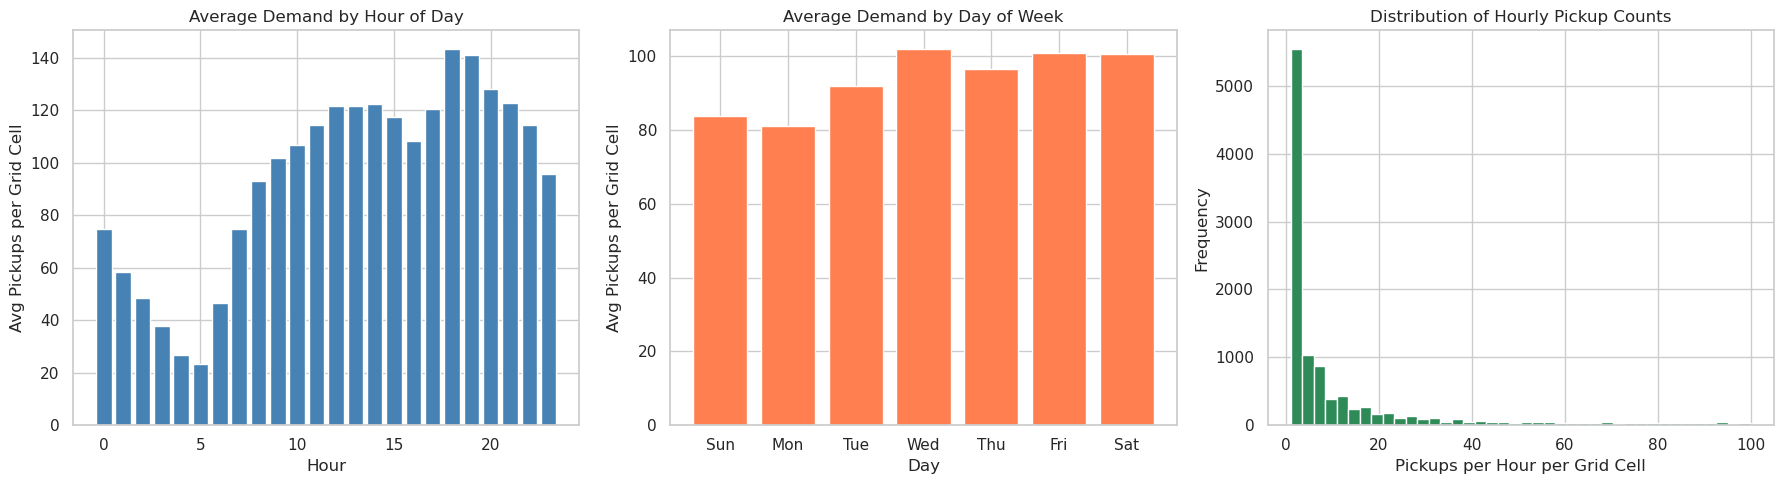

EDA plots saved to eda_plots.png


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average hourly pickup demand across the day 
hourly_pd = (
    demand_df
    .groupBy("pickup_hour")
    .agg(F.avg("hourly_pickup_count").alias("avg_demand"))
    .orderBy("pickup_hour")
    .toPandas()
)
axes[0].bar(hourly_pd["pickup_hour"], hourly_pd["avg_demand"], color="steelblue")
axes[0].set_title("Average Demand by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Pickups per Grid Cell")

# Plot 2: Average demand by day of week 
dow_map = {1:"Sun",2:"Mon",3:"Tue",4:"Wed",5:"Thu",6:"Fri",7:"Sat"}
dow_pd = (
    demand_df
    .groupBy("pickup_day_of_week")
    .agg(F.avg("hourly_pickup_count").alias("avg_demand"))
    .orderBy("pickup_day_of_week")
    .toPandas()
)
dow_pd["day"] = dow_pd["pickup_day_of_week"].map(dow_map)
axes[1].bar(dow_pd["day"], dow_pd["avg_demand"], color="coral")
axes[1].set_title("Average Demand by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Pickups per Grid Cell")

# Plot 3: Distribution of hourly pickup counts
count_sample_pd = (
    demand_df
    .select("hourly_pickup_count")
    .filter(F.col("hourly_pickup_count") <= 100)  
    .sample(fraction=0.1, seed=42)
    .toPandas()
)
axes[2].hist(count_sample_pd["hourly_pickup_count"], bins=40, color="seagreen", edgecolor="white")
axes[2].set_title("Distribution of Hourly Pickup Counts")
axes[2].set_xlabel("Pickups per Hour per Grid Cell")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved to eda_plots.png")

## 8. Feature Summary & Runtime Report

In [21]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"Raw rows loaded       : {row_count:,}")
print(f"Rows after cleaning   : {cleaned_count:,}")
print(f"Unique grid cells     : {n_cells:,}")
print(f"Demand agg rows       : {demand_df.count():,}")
print(f"Final feature rows    : {final_features_df.count():,}")
print()
print("Features created:")
for col_name in final_features_df.columns:
    print(f"  • {col_name}")
print()
print("Target variable       : hourly_pickup_count")
print("Output written to     :", FEATURES_PATH)

FEATURE ENGINEERING SUMMARY
Raw rows loaded       : 12,748,986
Rows after cleaning   : 12,418,120
Unique grid cells     : 1,089


Demand agg rows       : 131,050


Final feature rows    : 117,640

Features created:
  • grid_cell
  • pickup_date
  • pickup_hour
  • pickup_day_of_week
  • is_weekend
  • is_rush_hour
  • is_holiday
  • time_of_day
  • hourly_pickup_count
  • avg_trip_distance
  • avg_trip_duration
  • avg_speed
  • avg_tip_rate
  • avg_fare
  • hour_index
  • demand_lag_1h
  • demand_lag_2h
  • demand_lag_24h
  • rolling_avg_3h

Target variable       : hourly_pickup_count
Output written to     : gs://bucket2326/features_2015_01.parquet


In [23]:
# Clean up caches 
taxi_df.unpersist()
demand_df.unpersist()
print("Caches released.")

Caches released.


# Deliverable 3: Model Training and Evaluation

In this section, we continue from the feature engineering pipeline and use the saved feature dataset to train and compare Spark MLlib regression models for taxi demand prediction.

**Goal:** Predict `hourly_pickup_count` using the engineered temporal, trip-level, spatial, and lag-based features.

**Models compared:**
1. Random Forest Regressor
2. Decision Tree Regressor
3. Linear Regression (baseline model)

*Note:* We initially considered Gradient Boosted Trees, but due to high computational cost and long training time in the current environment, we instead included Linear Regression as a baseline and Decision Tree as a simpler tree-based model for comparison.

**Evaluation metrics:**
- RMSE
- MAE

We also record model training time to analyze the tradeoff between predictive performance and computational efficiency.

In [1]:
# 1. We are going to start with loading the saved feature dataset

from pyspark.sql import functions as F
import time

# Path to the final feature-engineered dataset created in Deliverable 2
FEATURES_PATH = "gs://bucket2326/features_2015_01.parquet"

t0 = time.time()

ml_df = spark.read.parquet(FEATURES_PATH)

load_time = time.time() - t0

print("Feature dataset load")
print(f"Loaded feature dataset in {load_time:.1f}s")
print(f"Row count: {ml_df.count():,}")
print(f"Column count: {len(ml_df.columns)}")
print()

print("Columns:")
for c in ml_df.columns:
    print(f" - {c}")

print()
print("Schema:")
ml_df.printSchema()

print()
print("Sample rows:")
ml_df.show(5, truncate=False)

Feature dataset load
Loaded feature dataset in 7.6s


Row count: 117,640
Column count: 19

Columns:
 - grid_cell
 - pickup_date
 - pickup_hour
 - pickup_day_of_week
 - is_weekend
 - is_rush_hour
 - is_holiday
 - time_of_day
 - hourly_pickup_count
 - avg_trip_distance
 - avg_trip_duration
 - avg_speed
 - avg_tip_rate
 - avg_fare
 - hour_index
 - demand_lag_1h
 - demand_lag_2h
 - demand_lag_24h
 - rolling_avg_3h

Schema:
root
 |-- grid_cell: string (nullable = true)
 |-- pickup_date: date (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- hourly_pickup_count: long (nullable = true)
 |-- avg_trip_distance: double (nullable = true)
 |-- avg_trip_duration: double (nullable = true)
 |-- avg_speed: double (nullable = true)
 |-- avg_tip_rate: double (nullable = true)
 |-- avg_fare: double (nullable = true)
 |-

+------------+-----------+-----------+------------------+----------+------------+----------+-----------+-------------------+-----------------+------------------+------------------+------------+--------+----------+-------------+-------------+--------------+--------------+
|grid_cell   |pickup_date|pickup_hour|pickup_day_of_week|is_weekend|is_rush_hour|is_holiday|time_of_day|hourly_pickup_count|avg_trip_distance|avg_trip_duration |avg_speed         |avg_tip_rate|avg_fare|hour_index|demand_lag_1h|demand_lag_2h|demand_lag_24h|rolling_avg_3h|
+------------+-----------+-----------+------------------+----------+------------+----------+-----------+-------------------+-----------------+------------------+------------------+------------+--------+----------+-------------+-------------+--------------+--------------+
|40.58_-73.96|2015-01-14 |17         |4                 |0         |1           |0         |evening    |1                  |0.68             |4.233333333333333 |9.637795275590552 |0.0 

## 2: Define Modeling Columns and Check Data Quality

Before training models, we define the target column and the predictor columns we will use.

We separate predictors into:
- **categorical features** that need indexing/encoding
- **numeric features** that can go directly into the feature vector

We also check for null values in the modeling columns so we can avoid pipeline errors later.

In [2]:
# 2: Here, we will define label and predictor columns

# Target column we want to predict
label_col = "hourly_pickup_count"

# Categorical columns:
# - grid_cell shows the pickup location bucket
# - time_of_day is a string category we created during feature engineering
categorical_cols = [
    "grid_cell",
    "time_of_day"
]

# Numeric columns:
numeric_cols = [
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "is_rush_hour",
    "is_holiday",
    "avg_trip_distance",
    "avg_trip_duration",
    "avg_speed",
    "avg_tip_rate",
    "avg_fare",
    "hour_index",
    "demand_lag_1h",
    "demand_lag_2h",
    "demand_lag_24h",
    "rolling_avg_3h"
]

# All columns required for modeling
model_cols = [label_col] + categorical_cols + numeric_cols

print("Modeling column summary")
print(f"Label column: {label_col}")
print()
print("Categorical columns:")
for c in categorical_cols:
    print(f" - {c}")

print()
print("Numeric columns:")
for c in numeric_cols:
    print(f" - {c}")

print()
print(f"Total modeling columns (including label): {len(model_cols)}")

# Null check just to check for missing values:
null_exprs = [
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in model_cols
]

null_summary = ml_df.select(*null_exprs)

print()
print("Null counts for modeling columns:")
null_summary.show(truncate=False)

# Show only the columns we plan to use
print("Sample of modeling dataset:")
ml_df.select(model_cols).show(5, truncate=False)

Modeling column summary
Label column: hourly_pickup_count

Categorical columns:
 - grid_cell
 - time_of_day

Numeric columns:
 - pickup_hour
 - pickup_day_of_week
 - is_weekend
 - is_rush_hour
 - is_holiday
 - avg_trip_distance
 - avg_trip_duration
 - avg_speed
 - avg_tip_rate
 - avg_fare
 - hour_index
 - demand_lag_1h
 - demand_lag_2h
 - demand_lag_24h
 - rolling_avg_3h

Total modeling columns (including label): 18

Null counts for modeling columns:


+-------------------+---------+-----------+-----------+------------------+----------+------------+----------+-----------------+-----------------+---------+------------+--------+----------+-------------+-------------+--------------+--------------+
|hourly_pickup_count|grid_cell|time_of_day|pickup_hour|pickup_day_of_week|is_weekend|is_rush_hour|is_holiday|avg_trip_distance|avg_trip_duration|avg_speed|avg_tip_rate|avg_fare|hour_index|demand_lag_1h|demand_lag_2h|demand_lag_24h|rolling_avg_3h|
+-------------------+---------+-----------+-----------+------------------+----------+------------+----------+-----------------+-----------------+---------+------------+--------+----------+-------------+-------------+--------------+--------------+
|0                  |0        |0          |0          |0                 |0         |0           |0         |0                |0                |0        |0           |0       |0         |0            |0            |0             |0             |
+-----------

## 3: Train-Test Split

Before building models, we split the feature dataset into training and test sets.

- The **training set** is used to fit the models
- The **test set** is used only for evaluation

We use an 80/20 random split with a fixed seed so results are reproducible.

In [3]:
# 3: Train-test split

# Keep only the columns needed for modeling
model_df = ml_df.select(model_cols)

# Split into train and test sets
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

print("Train/test split")
print(f"Training rows: {train_df.count():,}")
print(f"Test rows    : {test_df.count():,}")
print(f"Total rows   : {train_df.count() + test_df.count():,}")

Train/test split


Training rows: 94,097


Test rows    : 23,543


Total rows   : 117,640


## 4: Feature Engineering for ML (Encoding + Vector Assembly)

Spark ML models require all features to be in a single vector column.

1. Convert categorical columns into numeric indices using `StringIndexer`
2. Assemble all features into a single vector using `VectorAssembler`

This creates the final dataset used for model training.

In [4]:
# 4A: Build preprocessing pipeline

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# a: Index categorical columns
# Converts strings to numeric indices
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

# b: Define final feature columns
# (indexed categorical + numeric)
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols

# c: Assemble features into a single vector column
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# d: Create pipeline
pipeline = Pipeline(stages=indexers + [assembler])

print("Pipeline stages:")
for stage in pipeline.getStages():
    print(" -", stage)

Pipeline stages:
 - StringIndexer_62ffe8f36ef6
 - StringIndexer_26ffa2466ea9
 - VectorAssembler_523052a3e509


In [5]:
# 4B: Apply preprocessing pipeline

t0 = time.time()

# Fit on training data
pipeline_model = pipeline.fit(train_df)

# Transform both train and test
train_prepared = pipeline_model.transform(train_df)
test_prepared = pipeline_model.transform(test_df)

prep_time = time.time() - t0

print("Feature pipeline complete")
print(f"Pipeline runtime: {prep_time:.1f}s")

print()
print("Final columns available:")
train_prepared.select("features", label_col).show(5, truncate=False)

Feature pipeline complete
Pipeline runtime: 20.3s

Final columns available:


26/04/11 20:30:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------------------------------------------------------------------------------------------------------+-------------------+
|features                                                                                                  |hourly_pickup_count|
+----------------------------------------------------------------------------------------------------------+-------------------+
|[314.0,2.0,12.0,2.0,0.0,0.0,0.0,1.45,7.4,11.756756756756756,0.2785714285714286,7.0,612.0,1.0,1.0,1.0,1.0] |1                  |
|[314.0,2.0,13.0,2.0,0.0,0.0,1.0,3.16,8.95,21.184357541899445,0.0,11.5,445.0,1.0,1.0,1.0,1.0]              |1                  |
|[314.0,2.0,15.0,4.0,0.0,0.0,0.0,0.4,1.8166666666666667,13.211009174311927,0.0,3.5,663.0,1.0,1.0,1.0,1.0]  |1                  |
|[314.0,2.0,15.0,5.0,0.0,0.0,0.0,8.37,45.2,11.110619469026547,0.0,34.5,519.0,1.0,1.0,1.0,1.0]              |1                  |
|[314.0,2.0,16.0,7.0,1.0,1.0,0.0,12.7,26.966666666666665,28.257107540173052,0.0,37.5,736.0,1.0,1.

## 5: Train Random Forest Regressor

We train a Random Forest regression model using the prepared feature dataset.

Random Forest is an ensemble method that builds multiple decision trees and averages their predictions, making it robust to noise and overfitting.

We also record training time to analyze performance.

In [6]:
# 5: Train Random Forest Regressor

from pyspark.ml.regression import RandomForestRegressor

# Random Forest model
# maxBins must be greater than or equal to number of distinct values in categorical features
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=label_col,
    numTrees=50,
    maxDepth=10,
    maxBins=512,   
    seed=42
)

# Train model
t0 = time.time()
rf_model = rf.fit(train_prepared)
rf_train_time = time.time() - t0

print("Random Forest Trained")
print(f"Training time: {rf_train_time:.1f}s")
print(f"maxBins used: 512")

26/04/11 20:31:05 WARN DAGScheduler: Broadcasting large task binary with size 1529.2 KiB
26/04/11 20:31:11 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/04/11 20:31:18 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/04/11 20:31:24 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
26/04/11 20:31:29 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
26/04/11 20:31:35 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/04/11 20:31:40 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


Random Forest Trained
Training time: 70.2s
maxBins used: 512


In [7]:
# 5B: Evaluate Random Forest

from pyspark.ml.evaluation import RegressionEvaluator

# Make predictions on test set
rf_predictions = rf_model.transform(test_prepared)

# Evaluate using RMSE and MAE
rmse_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="mae"
)

rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_mae = mae_evaluator.evaluate(rf_predictions)

print("Random forest performance")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")

# Show sample predictions
print("\nSample predictions:")
rf_predictions.select(label_col, "prediction").show(5, truncate=False)

Random forest performance
RMSE: 32.8263
MAE : 12.9763

Sample predictions:
+-------------------+------------------+
|hourly_pickup_count|prediction        |
+-------------------+------------------+
|1                  |1.2345789867410542|
|1                  |1.4223918830778866|
|1                  |1.4485941771837838|
|1                  |1.2302725328200488|
|1                  |1.2852830873997005|
+-------------------+------------------+
only showing top 5 rows



## 6: Train Linear Regression Baseline

Gradient Boosted Trees were computationally expensive in our current cluster setup, so we use Linear Regression as a faster baseline model for comparison.

This gives us a useful contrast between a linear model and a non-linear ensemble model (Random Forest)

We evaluate both using RMSE and MAE.

In [8]:
# 6A: Train Linear Regression

from pyspark.ml.regression import LinearRegression

# Linear Regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol=label_col,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.1,      # small regularization for stability
    elasticNetParam=0.0
)

# Train model
t0 = time.time()
lr_model = lr.fit(train_prepared)
lr_train_time = time.time() - t0

print("Linear Regression trained")
print(f"Training time: {lr_train_time:.1f}s")

Linear Regression trained
Training time: 3.7s


In [9]:
# 6B: Evaluate Linear Regression

from pyspark.ml.evaluation import RegressionEvaluator

# Make predictions
lr_predictions = lr_model.transform(test_prepared)

# Evaluators
rmse_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="mae"
)

# Metrics
lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_mae = mae_evaluator.evaluate(lr_predictions)

print("LINEAR REGRESSION PERFORMANCE")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE : {lr_mae:.4f}")

print("\nSample predictions:")
lr_predictions.select(label_col, "prediction").show(5, truncate=False)

LINEAR REGRESSION PERFORMANCE
RMSE: 46.9332
MAE : 19.7378

Sample predictions:
+-------------------+-------------------+
|hourly_pickup_count|prediction         |
+-------------------+-------------------+
|1                  |-2.787817594242659 |
|1                  |5.7898510965338    |
|1                  |3.7491011025048415 |
|1                  |-8.876681581556396 |
|1                  |-10.543810052267792|
+-------------------+-------------------+
only showing top 5 rows



## 7: Train Decision Tree Regressor

We train a Decision Tree regression model as a simpler alternative to Random Forest.

This helps us compare: single tree vs ensemble model and model complexity vs performance

In [10]:
# 7: Train Decision Tree

from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol=label_col,
    maxDepth=10,
    maxBins=512,
    seed=42
)

t0 = time.time()
dt_model = dt.fit(train_prepared)
dt_train_time = time.time() - t0

print("Decision tree trained")
print(f"Training time: {dt_train_time:.1f}s")

Decision tree trained
Training time: 8.1s


In [11]:
# 7B: Evaluate Decision Tree

dt_predictions = dt_model.transform(test_prepared)

dt_rmse = rmse_evaluator.evaluate(dt_predictions)
dt_mae = mae_evaluator.evaluate(dt_predictions)

print("Decision tree performance")
print(f"RMSE: {dt_rmse:.4f}")
print(f"MAE : {dt_mae:.4f}")

Decision tree performance
RMSE: 43.5659
MAE : 15.5664


## 8: Final Model Comparison

We compare three models:

- Linear Regression (baseline)
- Decision Tree (single-tree model)
- Random Forest (ensemble model)

This comparison highlights the tradeoff between accuracy, model complexity, and training time

In [12]:
# 8: Final comparison (3 models)

results = [
    ("Random Forest", rf_rmse, rf_mae, rf_train_time),
    ("Decision Tree", dt_rmse, dt_mae, dt_train_time),
    ("Linear Regression", lr_rmse, lr_mae, lr_train_time)
]

results_df = spark.createDataFrame(
    results,
    ["Model", "RMSE", "MAE", "Training_Time_sec"]
)

print("Final Model Comparison")

results_df.show(truncate=False)

print("\nSorted by RMSE (best model first):")
results_df.orderBy("RMSE").show(truncate=False)

Final Model Comparison


+-----------------+-----------------+------------------+------------------+
|Model            |RMSE             |MAE               |Training_Time_sec |
+-----------------+-----------------+------------------+------------------+
|Random Forest    |32.82634026812063|12.97633149202583 |70.21795082092285 |
|Decision Tree    |43.56586724641111|15.56644863901158 |8.103047609329224 |
|Linear Regression|46.93322497049497|19.737784420353847|3.6765835285186768|
+-----------------+-----------------+------------------+------------------+


Sorted by RMSE (best model first):
+-----------------+-----------------+------------------+------------------+
|Model            |RMSE             |MAE               |Training_Time_sec |
+-----------------+-----------------+------------------+------------------+
|Random Forest    |32.82634026812063|12.97633149202583 |70.21795082092285 |
|Decision Tree    |43.56586724641111|15.56644863901158 |8.103047609329224 |
|Linear Regression|46.93322497049497|19.73778442035

## Model comparison insights from above

We compared three models: Linear Regression, Decision Tree, and Random Forest.

The Random Forest model achieved the best performance, with the lowest RMSE (33.83) and MAE (12.98), showing that it captures complex patterns in the data effectively. However, it also had the highest training time (about 70 seconds).

The Decision Tree performed moderately well, improving over Linear Regression but falling short of Random Forest. This shows that a single tree is not sufficient to model the complexity of the data.

Linear Regression had the highest error (RMSE: 46.93), indicating that the relationship between features and target is not purely linear.

There is a clear tradeoff between accuracy and training time. Random Forest provides the best predictive performance, while Linear Regression is the fastest but least accurate.